In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [3]:
df = pd.read_csv("netflix_titles.csv")
df = df.drop_duplicates(subset="title").reset_index(drop=True)

tv = df[df["type"] == "TV Show"].copy()
tv["seasons"] = tv["duration"].str.extract(r"(\d+)").astype(float)
tv = tv.dropna(subset=["seasons"])

print(f"TV shows in dataset: {len(tv)}")
print(tv["seasons"].describe())

TV shows in dataset: 2663
count    2663.000000
mean        1.752159
std         1.550844
min         1.000000
25%         1.000000
50%         1.000000
75%         2.000000
max        17.000000
Name: seasons, dtype: float64


In [6]:
for col in ["country", "listed_in", "director", "rating"]:
    tv[col] = tv[col].fillna("Unknown")

tv["primary_country"] = tv["country"].apply(lambda x: x.split(",")[0].strip())
tv["primary_genre"] = tv["listed_in"].apply(lambda x: x.split(",")[0].strip())
tv["genre_count"] = tv["listed_in"].apply(lambda x: len(x.split(",")))
tv["has_director"] = (tv["director"] != "Unknown").astype(int)

feature_cols = ["primary_country", "primary_genre", "rating",
                 "release_year", "genre_count", "has_director"]
X = tv[feature_cols].copy()

encoders = {}
for col in ["primary_country", "primary_genre", "rating"]:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    encoders[col] = le

y = tv["seasons"]

print("Feature matrix shape:", X.shape)
X.head()

Feature matrix shape: (2663, 6)


,primary_country,primary_genre,rating,release_year,genre_count,has_director
1,16,3,4,2021,3,1
2,57,13,4,2021,3,1
5,56,1,2,2021,2,1
17,38,4,4,2021,2,1
18,38,1,4,2021,3,1


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=200, random_state=42, max_depth=8),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=200, random_state=42, max_depth=3),
}

for name, model in models.items():
    model.fit(X_train, y_train)

print("Trained models:", list(models.keys()))

Trained models: ['Linear Regression', 'Random Forest', 'Gradient Boosting']


In [8]:
results = {}
for name, model in models.items():
    preds = model.predict(X_test)
    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)
    results[name] = {"MAE": mae, "RMSE": rmse, "R2": r2}
    print(f"\n--- {name} ---")
    print(f"MAE:  {mae:.2f} seasons")
    print(f"RMSE: {rmse:.2f} seasons")
    print(f"R²:   {r2:.3f}")

best_name = max(results, key=lambda n: results[n]["R2"])
best_model = models[best_name]
print(f"\nBest model: {best_name} (R² = {results[best_name]['R2']:.3f})")


--- Linear Regression ---
MAE:  1.01 seasons
RMSE: 1.58 seasons
R²:   0.037

--- Random Forest ---
MAE:  0.91 seasons
RMSE: 1.56 seasons
R²:   0.058

--- Gradient Boosting ---
MAE:  0.90 seasons
RMSE: 1.53 seasons
R²:   0.092

Best model: Gradient Boosting (R² = 0.092)


In [9]:
importances = pd.Series(
    getattr(best_model, "feature_importances_", np.zeros(len(feature_cols))),
    index=feature_cols
).sort_values(ascending=False)
print("Feature importance (what drives season count predictions):")
print(importances)

# Which genres tend to run the longest, on average? (only genres with
# a reasonable sample size, to avoid one-off outliers dominating)
genre_stats = tv.groupby("primary_genre")["seasons"].agg(["mean", "count"])
genre_stats = genre_stats[genre_stats["count"] >= 15].sort_values("mean", ascending=False)
print("\nTop genres by average season count (min. 15 titles):")
print(genre_stats.head(10))

# Which countries tend to produce longer-running shows?
country_stats = tv.groupby("primary_country")["seasons"].agg(["mean", "count"])
country_stats = country_stats[country_stats["count"] >= 15].sort_values("mean", ascending=False)
print("\nTop countries by average season count (min. 15 titles):")
print(country_stats.head(10))

Feature importance (what drives season count predictions):
release_year       0.308761
primary_genre      0.289067
primary_country    0.276940
rating             0.072253
genre_count        0.052979
has_director       0.000000
dtype: float64

Top genres by average season count (min. 15 titles):
                                  mean  count
primary_genre                                
Classic & Cult TV             5.250000     20
TV Comedies                   3.016807    119
TV Dramas                     2.865672     67
Romantic TV Shows             2.843750     32
TV Action & Adventure         2.692308     39
Stand-Up Comedy & Talk Shows  2.176471     34
Kids' TV                      1.989610    385
British TV Shows              1.817460    252
Crime TV Shows                1.706767    399
Anime Series                  1.574713    174

Top countries by average season count (min. 15 titles):
                     mean  count
primary_country                 
Canada           2.607143    

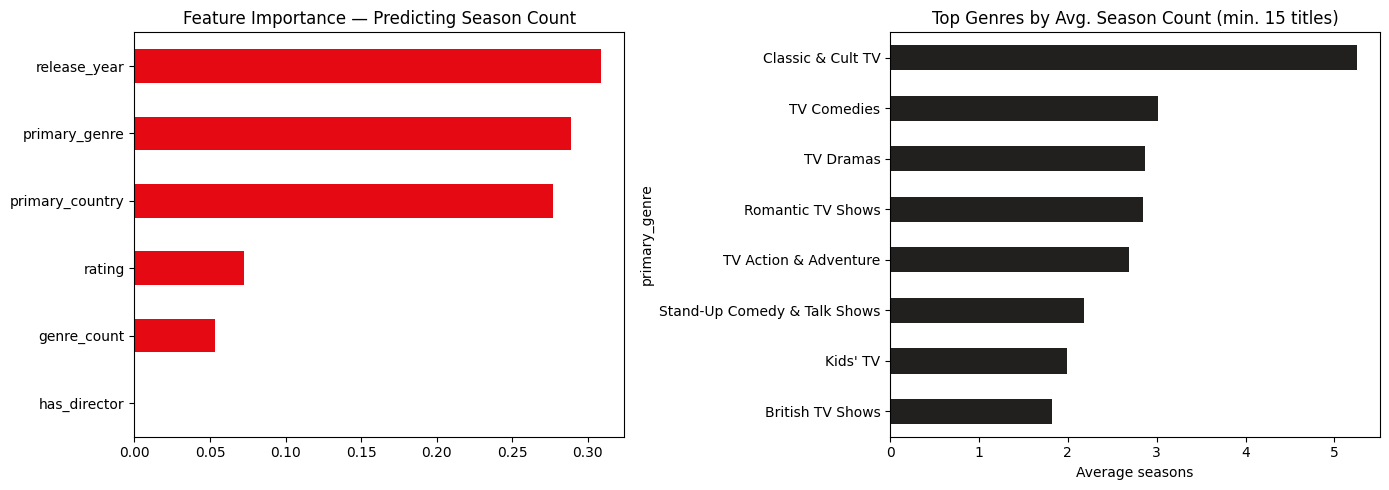

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

importances.plot(kind="barh", ax=axes[0], color="#E50914")
axes[0].set_title("Feature Importance — Predicting Season Count")
axes[0].invert_yaxis()

genre_stats.head(8)["mean"].plot(kind="barh", ax=axes[1], color="#221F1F")
axes[1].set_title("Top Genres by Avg. Season Count (min. 15 titles)")
axes[1].invert_yaxis()
axes[1].set_xlabel("Average seasons")

plt.tight_layout()
plt.show()

In [11]:
top_genre = genre_stats.index[0]
top_genre_avg = genre_stats.iloc[0]["mean"]
top_country = country_stats.index[0]
top_country_avg = country_stats.iloc[0]["mean"]
top_feature = importances.index[0]

print("=" * 60)
print("AUTOMATED INSIGHT SUMMARY")
print("=" * 60)
print(f"""
1. The single strongest predictor of a show's season count is
   '{top_feature}', suggesting renewal patterns are more tied to
   {'where a show is made' if 'country' in top_feature else
    'content category' if 'genre' in top_feature else
    'when it launched' if 'year' in top_feature else 'this factor'}
   than other attributes in this dataset.

2. '{top_genre}' titles average the highest season count among genres
   with a meaningful sample size ({top_genre_avg:.1f} seasons),
   suggesting this genre sustains longer-term audience engagement.

3. Shows from {top_country} average the longest runs among countries
   with a meaningful sample size ({top_country_avg:.1f} seasons).

4. Model performance (R² = {results[best_name]['R2']:.3f}) confirms this
   dataset's metadata alone offers only partial explanatory power over
   renewal outcomes -- as expected, since it lacks viewership, budget,
   or critical reception data. Genre and country patterns above should
   be read as directional signals, not guarantees.
""")

AUTOMATED INSIGHT SUMMARY

1. The single strongest predictor of a show's season count is
   'release_year', suggesting renewal patterns are more tied to
   when it launched
   than other attributes in this dataset.
 
2. 'Classic & Cult TV' titles average the highest season count among genres
   with a meaningful sample size (5.2 seasons),
   suggesting this genre sustains longer-term audience engagement.
 
3. Shows from Canada average the longest runs among countries
   with a meaningful sample size (2.6 seasons).
 
4. Model performance (R² = 0.092) confirms this
   dataset's metadata alone offers only partial explanatory power over
   renewal outcomes -- as expected, since it lacks viewership, budget,
   or critical reception data. Genre and country patterns above should
   be read as directional signals, not guarantees.

